# 1. Import Libraries

In [7]:
!pip install transformers torch nltk tokenizers


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


# 2. Import Pipeline

In [8]:
from transformers import pipeline

pretrained_name = "w11wo/indonesian-roberta-base-sentiment-classifier"

classifier = pipeline(
    "sentiment-analysis",
    model=pretrained_name,
    tokenizer=pretrained_name,
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7641.56it/s]


# 3. Try Model

In [9]:
text = "Ekonomi Indonesia sedang tumbuh dengan baik"
print(classifier(text))

text = "Ekonomi Indonesia sedang tumbuh dengan jelek"
print(classifier(text))

[{'label': 'positive', 'score': 0.9899829626083374}]
[{'label': 'negative', 'score': 0.9991164803504944}]


# 4. Import Data

In [12]:
import pandas as pd

df = pd.read_csv("../../preprocessed/dataset_preprocessed_razan.csv")
df

,url,judul,konten,manual sentiment,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,resmi milik presiden sambut positif agenda pro...
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,nilai tukar rupiah dolar kuat lantik presiden ...
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,pasar uang kuat lantik presiden indeks harga s...
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,indeks harga saham gabung ihsg ambruk level pu...
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,hargabitcoin btc lewat angka tinggi kisara pic...
...,...,...,...,...,...
994,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,produsen mesin tambang bitcoin besar dunia chi...
995,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Netral,presiden aku serang sulit langkah ketua fed je...
996,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,bisnis com serang fasilitas nuklir utama iran ...
997,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,usaha semikonduktor texas instruments ti umum ...


# EDA

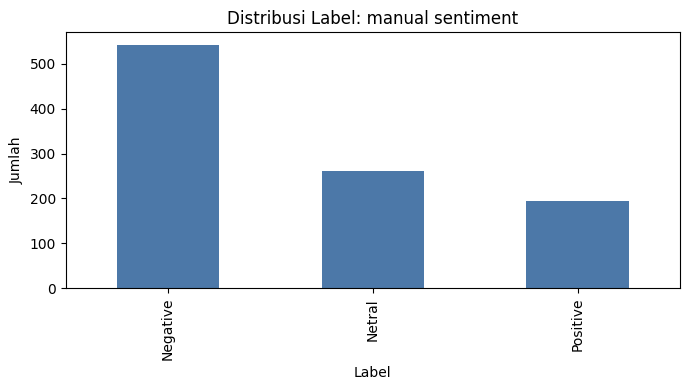

,count
manual sentiment,
Negative,543
Netral,261
Positive,195


In [13]:
import matplotlib.pyplot as plt

# Pick a label column that exists in the dataset
label_candidates = [
    "manual sentiment",
    # "label",
    # "sentiment",
    # "true_label",
    # "pred_label",
    # "label_bert",
]
label_col = next((col for col in label_candidates if col in df.columns), None)
if label_col is None:
    raise ValueError(f"No label column found. Available columns: {list(df.columns)}")

label_counts = df[label_col].value_counts(dropna=False).sort_index()

ax = label_counts.plot(kind="bar", color="#4C78A8", figsize=(7, 4))
ax.set_title(f"Distribusi Label: {label_col}")
ax.set_xlabel("Label")
ax.set_ylabel("Jumlah")
plt.tight_layout()
plt.show()

label_counts.to_frame("count")

# 5. Perform Sentiment Analysis

In [14]:
df["sentiment_bert"] = df["konten_preprocessed"].apply(lambda x: classifier(x[:256])[0])

df["label_bert"] = df["sentiment_bert"].apply(lambda x: x["label"])
df["score_bert"] = df["sentiment_bert"].apply(lambda x: x["score"])

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [15]:
df

,url,judul,konten,manual sentiment,konten_preprocessed,sentiment_bert,label_bert,score_bert
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,resmi milik presiden sambut positif agenda pro...,"{'label': 'neutral', 'score': 0.998284637928009}",neutral,0.998285
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,nilai tukar rupiah dolar kuat lantik presiden ...,"{'label': 'neutral', 'score': 0.9963177442550659}",neutral,0.996318
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,pasar uang kuat lantik presiden indeks harga s...,"{'label': 'neutral', 'score': 0.9955258965492249}",neutral,0.995526
3,https://www.cnbcindonesia.com/research/2025030...,"IHSG Merah Lagi, Begini Penjelasan dari Analis...","Jakarta, CNBC Indonesia -Indeks Harga Saham Ga...",Negative,indeks harga saham gabung ihsg ambruk level pu...,"{'label': 'neutral', 'score': 0.9969793558120728}",neutral,0.996979
4,https://indodax.com/academy/bitcoin-200k-predi...,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,HargaBitcoin(BTC)pernah melewati angka terting...,Positive,hargabitcoin btc lewat angka tinggi kisara pic...,"{'label': 'neutral', 'score': 0.9969125986099243}",neutral,0.996913
...,...,...,...,...,...,...,...,...
994,https://voi.id/teknologi/489452/produsen-mesin...,Produsen Mesin Bitcoin China Pindahkan Produks...,JAKARTA - Tiga produsen mesin penambang bitcoi...,Positive,produsen mesin tambang bitcoin besar dunia chi...,"{'label': 'neutral', 'score': 0.998446524143219}",neutral,0.998447
995,https://www.liputan6.com/bisnis/read/6058462/d...,Donald Trump Kembali Tekan Ketua The Fed Jerom...,Presiden Amerika Serikat (AS) Donald Trump men...,Netral,presiden aku serang sulit langkah ketua fed je...,"{'label': 'neutral', 'score': 0.9906401634216309}",neutral,0.990640
996,https://kabar24.bisnis.com/read/20250622/19/18...,"Donald Trump Serang Iran, Ekonomi Global Bakal...","Bisnis.com,JAKARTA — Serangan Amerika Serikat ...",Negative,bisnis com serang fasilitas nuklir utama iran ...,"{'label': 'neutral', 'score': 0.9979543685913086}",neutral,0.997954
997,https://www.cnbcindonesia.com/tech/20250620153...,Trump 'Palak' Raksasa Teknologi Rp 900 Triliun...,"Jakarta, CNBC Indonesia -Perusahaan semikonduk...",Negative,usaha semikonduktor texas instruments ti umum ...,"{'label': 'neutral', 'score': 0.996866762638092}",neutral,0.996867


## Test Sentiment

In [16]:
# ambil text
texts = df["konten_preprocessed"].tolist()

# prediksi
predictions = classifier(
    texts,
    truncation=True,
    max_length=512,
    batch_size=8
)

# ambil label saja
df["pred_label"] = [pred["label"].lower() for pred in predictions]

In [17]:
label_map = {
    "positive": "positif",
    "negative": "negatif",
    "neutral": "Neutral"
}

df["pred_label"] = df["pred_label"].map(label_map)
df["true_label"] = df["manual sentiment"].str.lower()

In [18]:
df_clean = df.dropna(subset=["true_label", "pred_label"])
df_clean["true_label"] = df_clean["true_label"].astype(str)
df_clean["pred_label"] = df_clean["pred_label"].astype(str)

In [19]:
label_map = {
    "positive": "positif",
    "negative": "negatif",
    "neutral": "Neutral"
}

In [20]:
df[df["pred_label"].isna()][["konten_preprocessed"]].head()

,konten_preprocessed


In [21]:
# bersihin
df_clean = df.dropna(subset=["true_label", "pred_label"])

# ambil
y_true = df_clean["true_label"].astype(str)
y_pred = df_clean["pred_label"].astype(str)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Accuracy: 0.0
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Classification Report:
              precision    recall  f1-score   support

     Neutral       0.00      0.00      0.00       0.0
     negatif       0.00      0.00      0.00       0.0
    negative       0.00      0.00      0.00     543.0
      netral       0.00      0.00      0.00     261.0
    positive       0.00      0.00      0.00     195.0

    accuracy                           0.00     999.0
   macro avg       0.00      0.00      0.00     999.0
weighted avg       0.00      0.00      0.00     999.0



/home/lenovo/Documents/School/Sem6/PBA/pba-task-group/.env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lenovo/Documents/School/Sem6/PBA/pba-task-group/.env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lenovo/Documents/School/Sem6/PBA/pba-task-group/.env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

# fitur & label
X = df_clean["konten_preprocessed"]
y = df_clean["true_label"]

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# prediksi
y_pred = model.predict(X_test_tfidf)

# metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.585
Precision: 0.5400749167591564
Recall: 0.585
F1 Score: 0.5269067725283358

Classification Report:
              precision    recall  f1-score   support

    negative       0.62      0.91      0.74       109
      netral       0.38      0.17      0.24        52
    positive       0.53      0.23      0.32        39

    accuracy                           0.58       200
   macro avg       0.51      0.44      0.43       200
weighted avg       0.54      0.58      0.53       200



In [23]:
# ==============================
# COMPLETE PIPELINE (1 CELL)
# ==============================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
import pandas as pd

# ==============================
# 1. PREPARE DATA
# ==============================
df_clean = df.dropna(subset=["true_label", "konten_preprocessed"])

X = df_clean["konten_preprocessed"]
y = df_clean["true_label"].astype(str)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 2. TF-IDF (TUNED)
# ==============================
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,3),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# ==============================
# 3. MODELS
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced"),
    "Naive Bayes": MultinomialNB(alpha=0.5)
}

# ==============================
# 4. TRAIN + EVALUATE
# ==============================
results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    
    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# ==============================
# 5. SUMMARY TABLE
# ==============================
results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)

print("\n\n=== MODEL COMPARISON ===")
display(results_df)


===== Logistic Regression =====
Accuracy: 0.595
Precision: 0.5804047518923465
Recall: 0.595
F1 Score: 0.584182860040568

Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.78      0.73       109
      netral       0.40      0.37      0.38        52
    positive       0.52      0.38      0.44        39

    accuracy                           0.59       200
   macro avg       0.53      0.51      0.52       200
weighted avg       0.58      0.59      0.58       200


===== Linear SVM =====
Accuracy: 0.605
Precision: 0.579142801857585
Recall: 0.605
F1 Score: 0.5813015873015873

Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.83      0.74       109
      netral       0.42      0.31      0.36        52
    positive       0.54      0.36      0.43        39

    accuracy                           0.60       200
   macro avg       0.54      0.50      0.51       200
weighted avg

/home/lenovo/Documents/School/Sem6/PBA/pba-task-group/.env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lenovo/Documents/School/Sem6/PBA/pba-task-group/.env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lenovo/Documents/School/Sem6/PBA/pba-task-group/.env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.595,0.580405,0.595,0.584183
1,Linear SVM,0.605,0.579143,0.605,0.581302
2,Naive Bayes,0.550,0.375186,0.550,0.417069



===== Logistic Regression =====
Accuracy: 0.595
Precision: 0.5804047518923465
Recall: 0.595
F1 Score: 0.584182860040568

Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.78      0.73       109
      netral       0.40      0.37      0.38        52
    positive       0.52      0.38      0.44        39

    accuracy                           0.59       200
   macro avg       0.53      0.51      0.52       200
weighted avg       0.58      0.59      0.58       200



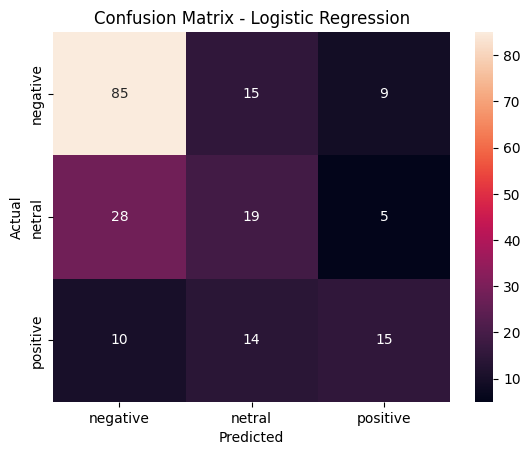


===== Linear SVM =====
Accuracy: 0.605
Precision: 0.579142801857585
Recall: 0.605
F1 Score: 0.5813015873015873

Classification Report:
              precision    recall  f1-score   support

    negative       0.67      0.83      0.74       109
      netral       0.42      0.31      0.36        52
    positive       0.54      0.36      0.43        39

    accuracy                           0.60       200
   macro avg       0.54      0.50      0.51       200
weighted avg       0.58      0.60      0.58       200



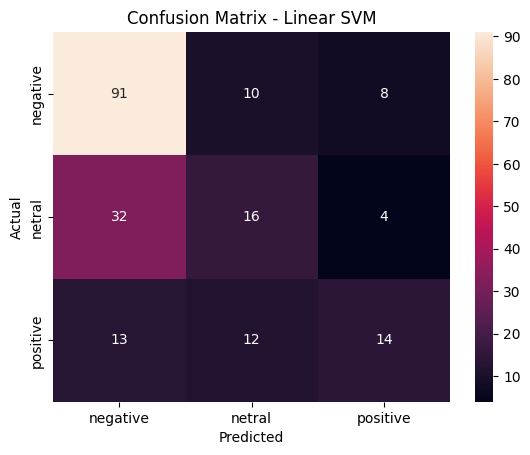


===== Naive Bayes =====
Accuracy: 0.55
Precision: 0.37518617021276596
Recall: 0.55
F1 Score: 0.4170686026936027

Classification Report:
              precision    recall  f1-score   support

    negative       0.57      0.98      0.72       109
      netral       0.25      0.06      0.09        52
    positive       0.00      0.00      0.00        39

    accuracy                           0.55       200
   macro avg       0.27      0.35      0.27       200
weighted avg       0.38      0.55      0.42       200



/home/lenovo/Documents/School/Sem6/PBA/pba-task-group/.env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lenovo/Documents/School/Sem6/PBA/pba-task-group/.env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/lenovo/Documents/School/Sem6/PBA/pba-task-group/.env/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

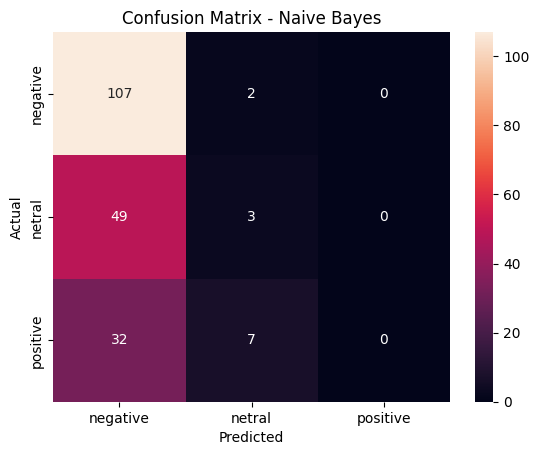

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    
    print(f"\n===== {name} =====")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # ==============================
    # CONFUSION MATRIX
    # ==============================
    cm = confusion_matrix(y_test, y_pred)
    labels = sorted(y_test.unique())
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# 6. Analyse Results

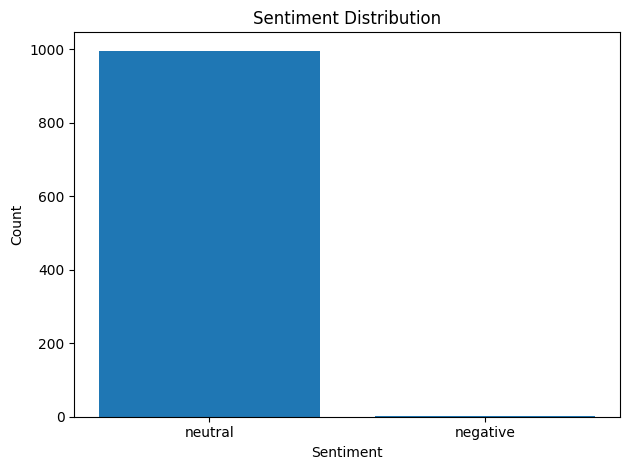

In [25]:
import matplotlib.pyplot as plt

counts = df["label_bert"].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Distribution")
plt.tight_layout()
plt.show()

# Citations

@misc {wilson_wongso_2023,
    author       = { {Wilson Wongso} },
    title        = { indonesian-roberta-base-sentiment-classifier (Revision e402e46) },
    year         = 2023,
    url          = { https://huggingface.co/w11wo/indonesian-roberta-base-sentiment-classifier },
    doi          = { 10.57967/hf/0644 },
    publisher    = { Hugging Face }
}